In [30]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Charter",
    "axes.titlesize": 22, # Main title at the top
    "axes.labelsize": 18, # X/y titles
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})


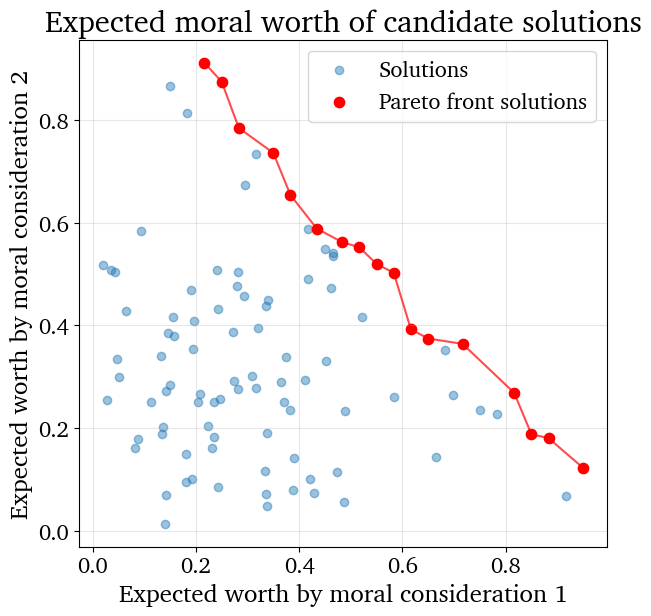

In [36]:

def is_dominated(point, others):
    """
    Returns True if `point` is Pareto dominated by any point in `others`,
    assuming both objectives are being maximised.

    A point x dominates y if:
    - x is at least as good as y in all objectives, and
    - x is strictly better in at least one objective.
    """
    return np.any(
        np.all(others >= point, axis=1) &
        np.any(others > point, axis=1)
    )


def pareto_front(points):
    """
    Extract nondominated points.
    """
    nondominated = []

    for i, p in enumerate(points):
        others = np.delete(points, i, axis=0)
        if not is_dominated(p, others):
            nondominated.append(p)

    return np.array(nondominated)


# -----------------------------
# Generate random objective data
# -----------------------------

np.random.seed(8)

n_points = 75

# Random candidate solutions
x = np.random.beta(2, 5, n_points)
y = np.random.beta(2, 5, n_points)

# Add a trade-off structure so the Pareto front is clearer
tradeoff_x = np.linspace(0.15, 0.95, 25)
tradeoff_y = 1.05 - tradeoff_x + np.random.normal(0, 0.04, 25)

points = np.vstack([
    np.column_stack([x, y]),
    np.column_stack([tradeoff_x, tradeoff_y])
])

# Keep values in [0, 1]
points = np.clip(points, 0, 1)


# -----------------------------
# Compute Pareto front
# -----------------------------

pf = pareto_front(points)

# Sort Pareto front by objective 1 for drawing a line through it
pf_sorted = pf[np.argsort(pf[:, 0])]


# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(6, 6))

# All candidate solutions
plt.scatter(
    points[:, 0],
    points[:, 1],
    alpha=0.45,
    label="Solutions"
)

# Pareto front
plt.scatter(
    pf[:, 0],
    pf[:, 1],
    color="red",
    s=55,
    label="Pareto front solutions"
)

# Optional line through Pareto front
plt.plot(
    pf_sorted[:, 0],
    pf_sorted[:, 1],
    color="red",
    linewidth=1.5,
    alpha=0.7
)


plt.xlabel("Expected worth by moral consideration 1")
plt.ylabel("Expected worth by moral consideration 2")
plt.title("Expected moral worth of candidate solutions")
plt.legend()
plt.grid(alpha=0.3)

# Useful for thesis-style figures
plt.tight_layout()
plt.show()


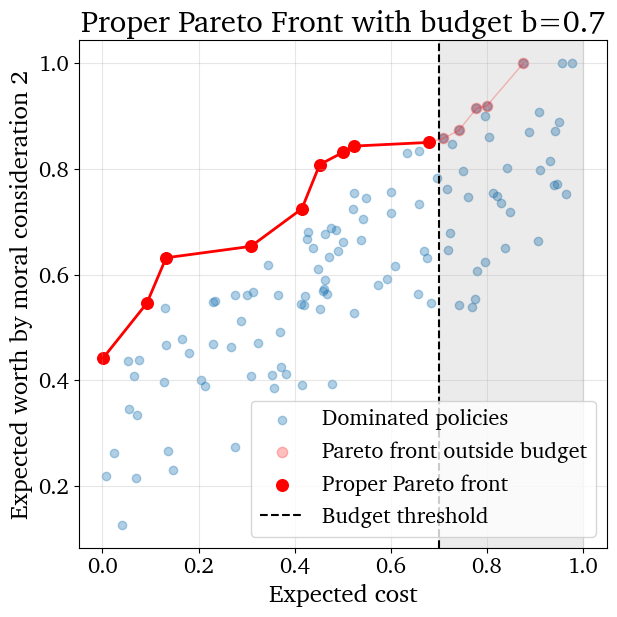

In [42]:
import numpy as np
import matplotlib.pyplot as plt


def is_dominated_mixed(point, others):
    """
    Returns True if `point` is dominated by any point in `others`.

    Assumption:
    - Objective 1, x-axis, is a cost/budget objective to minimise.
    - Objective 2, y-axis, is a value/worth objective to maximise.

    A point x dominates y if:
    - x has cost no greater than y,
    - x has value no less than y,
    - and x is strictly better in at least one objective.
    """
    return np.any(
        (others[:, 0] <= point[0]) &
        (others[:, 1] >= point[1]) &
        (
            (others[:, 0] < point[0]) |
            (others[:, 1] > point[1])
        )
    )


def pareto_front_mixed(points):
    """
    Extract nondominated points where objective 1 is minimised
    and objective 2 is maximised.
    """
    nondominated = []

    for i, p in enumerate(points):
        others = np.delete(points, i, axis=0)
        if not is_dominated_mixed(p, others):
            nondominated.append(p)

    return np.array(nondominated)


# -----------------------------
# Generate random objective data
# -----------------------------

np.random.seed(7)

n_points = 120

# Objective 1: cost / budget use
cost = np.random.uniform(0, 1, n_points)

# Objective 2: value / moral worth
# Add a rough trade-off: higher-cost policies tend to permit higher value.
value = 0.35 + 0.55 * cost + np.random.normal(0, 0.12, n_points)

points = np.column_stack([cost, value])
points = np.clip(points, 0, 1)


# -----------------------------
# Budget threshold
# -----------------------------

budget_threshold = 0.7


# -----------------------------
# Compute Pareto front
# -----------------------------

pf = pareto_front_mixed(points)

# Split the Pareto front into feasible and infeasible points
proper_pf = pf[pf[:, 0] <= budget_threshold]
infeasible_pf = pf[pf[:, 0] > budget_threshold]

# Sort for drawing lines
pf_sorted = pf[np.argsort(pf[:, 0])]
proper_pf_sorted = proper_pf[np.argsort(proper_pf[:, 0])]


# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(6, 6))

# All candidate policies
plt.scatter(
    points[:, 0],
    points[:, 1],
    alpha=0.35,
    label="Dominated policies"
)

# Pareto-optimal but budget-infeasible policies
plt.scatter(
    infeasible_pf[:, 0],
    infeasible_pf[:, 1],
    color="red",
    alpha=0.25,
    s=55,
    label="Pareto front outside budget"
)

# Proper Pareto front
plt.scatter(
    proper_pf[:, 0],
    proper_pf[:, 1],
    color="red",
    s=70,
    label="Proper Pareto front"
)

# Draw only the feasible part of the Pareto front strongly
plt.plot(
    proper_pf_sorted[:, 0],
    proper_pf_sorted[:, 1],
    color="red",
    linewidth=2
)

# Draw the full Pareto front faintly, to show what is excluded
plt.plot(
    pf_sorted[:, 0],
    pf_sorted[:, 1],
    color="red",
    linewidth=1,
    alpha=0.25
)

# Budget line
plt.axvline(
    x=budget_threshold,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Budget threshold"
)

# Optional shaded infeasible region
plt.axvspan(
    budget_threshold,
    1,
    alpha=0.08,
    color="black"
)

plt.xlabel("Expected cost")
plt.ylabel("Expected worth by moral consideration 2")
plt.title(f"Proper Pareto Front with budget b={budget_threshold}")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
